In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'scipy'

In [3]:
%pip install scipy matplotlib

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.6/36.6 MB 10.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.2/36.6 MB 11.2 MB/s eta 0:00:03
   ------- -------------------------------- 6.6/36.6 MB 11.4 MB/s eta 0:00:03
   ---------- ----------------------------- 9.2/36.6 MB 11.6 MB/s eta 0:00:03
   ------------ --------------------------- 11.8/36.6 MB 11.6 MB/s eta 0:00:03
   --------------- ------------------------ 14.4/36.6 MB 11.7 MB/s eta 0:00:02
   ------------------ --------------------- 16.8/36.6 MB 11.7 MB/s eta 0:00:02
   -------------------- ------------------- 18.9/36.6 MB 11.6 MB/s eta 0:00:02
   ---------------------- ----------------- 21.0/36.6 MB 11.4 MB/s eta 0:00:02
   ------------------------- -------------- 23.6/36.6 MB 11.3 MB/s eta 0:00:02
   ---------------------------- ----------- 25.7/36.6 MB 11.3 MB/s eta 0:00:01
   ------------------------------ --------- 28.0/36.6 MB 11.2 MB/


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

print("Бібліотеки підключено")

Бібліотеки підключено


In [5]:
np.random.seed(7)

daily_temps = np.random.normal(
    loc=17,
    scale=2.5,
    size=30
)

print("Денні температури:")
print(daily_temps)

print("Середнє:", daily_temps.mean())
print("Стандартне відхилення:", daily_temps.std())

Денні температури:
[21.22631426 15.83515657 17.08205041 18.01879071 15.02769243 17.00516393
 16.99777404 12.61318923 19.54414501 18.50124629 15.43642757 16.57112935
 18.26324844 16.34660896 16.3931273  13.36689647 18.38645078 17.30970226
 17.68614981 13.18368867 21.12674923 17.38583884 16.03215014 22.07268055
 16.88653493 13.37330325 15.98693036 11.27921225 19.62349137 15.9588142 ]
Середнє: 16.81735525365642
Стандартне відхилення: 2.4841459099575904


In [6]:
mean = daily_temps.mean()
std = daily_temps.std()

dist = stats.norm(loc=mean, scale=std)

print("Середнє:", mean)
print("Стандартне відхилення:", std)
print("Нормальний розподіл:", dist)

Середнє: 16.81735525365642
Стандартне відхилення: 2.4841459099575904
Нормальний розподіл: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001FD6ABF7CB0>


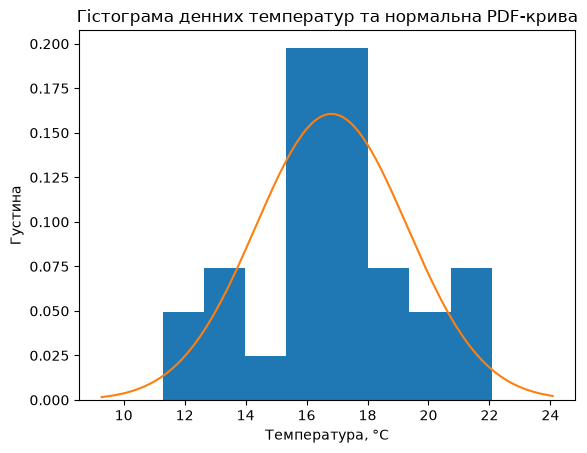

In [7]:
x = np.linspace(daily_temps.min() - 2, daily_temps.max() + 2, 200)

plt.hist(daily_temps, bins=8, density=True)
plt.plot(x, dist.pdf(x))

plt.xlabel("Температура, °C")
plt.ylabel("Густина")
plt.title("Гістограма денних температур та нормальна PDF-крива")
plt.show()

In [8]:
lower = mean - std
upper = mean + std

p = dist.cdf(upper) - dist.cdf(lower)

print("Нижня межа:", lower)
print("Верхня межа:", upper)
print("Ймовірність:", p)
print("У відсотках:", p * 100, "%")

Нижня межа: 14.33320934369883
Верхня межа: 19.30150116361401
Ймовірність: 0.6826894921370859
У відсотках: 68.26894921370858 %


In [9]:
q95 = dist.ppf(0.95)

print("95-й процентиль:", q95)

95-й процентиль: 20.90341166352683


In [10]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [11]:
dist = stats.norm(loc=mean, scale=std)

**1. Чим відрізняються `.pdf(x)` і `.cdf(x)`?**

`.pdf(x)` повертає значення щільності ймовірності в точці `x`. Це не є ймовірністю отримати саме це значення. `.cdf(x)` повертає накопичену ймовірність того, що випадкова величина буде меншою або дорівнюватиме `x`: `P(X ≤ x)`.

**2. Чому `.pdf(x)` може бути більше 1 і це не порушує правило, що ймовірність не може бути більшою за 1?**

Значення `.pdf(x)` є щільністю, а не самою ймовірністю. Ймовірність визначається як площа під кривою щільності на певному інтервалі. Тому щільність у деякій точці може бути більшою за 1, при цьому загальна площа під кривою дорівнює 1.

**3. Чому `.ppf()` називають оберненою функцією до `.cdf()`?**

`.cdf(x)` за заданим значенням `x` знаходить накопичену ймовірність. `.ppf(p)`, навпаки, за заданою ймовірністю `p` знаходить відповідне значення `x`. Тому `.ppf()` є оберненою функцією до `.cdf()`.